# Section 08 — Business Value and A/B Testing

NDCG went up. Now what?

Offline metrics prove a model ranks historical data better — but they don't prove the model creates business value. A recommender with NDCG +10% could translate to +2% CTR, +0% revenue, or even negative revenue if it pushes cheap items over high-margin ones.

This section answers: **how do you prove a recommender creates value?**

Topics covered:

1. **Sample size calculation** — how many users do you need to detect a given lift?
2. **A/B test simulator** — simulate an experiment under realistic assumptions about user behavior
3. **Statistical testing** — t-test and z-test for conversion rates; power analysis
4. **Revenue lift calculation** — translating engagement metrics to dollars
5. **Segment analysis** — did the model help all users or just some?
6. **Guardrail metrics** — what to monitor to prevent regressions
7. **Communicating results** — how to present this to stakeholders

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

## Part 1: Sample Size Calculation

Before running an A/B test, you need to know: **how many users do I need?**

The answer depends on three things:
- **Baseline rate**: current CTR or conversion rate (e.g., 5%)
- **Minimum detectable effect (MDE)**: smallest lift worth detecting (e.g., +0.5% absolute)
- **Desired power**: probability of detecting the effect if it's real (typically 80% or 90%)
- **Significance level α**: false positive rate (typically 5%)

Formula for two-proportion z-test:

$$n = \frac{(z_{\alpha/2} + z_{\beta})^2 \cdot (p_1(1-p_1) + p_2(1-p_2))}{(p_2 - p_1)^2}$$

where $p_1$ = baseline rate, $p_2 = p_1 + \text{MDE}$

In [2]:
def sample_size_per_group(baseline_rate, mde, alpha=0.05, power=0.80):
    """Minimum users per group (control/treatment) for two-proportion z-test.
    
    Args:
        baseline_rate: control group rate (e.g., 0.05 for 5% CTR)
        mde: minimum detectable effect, absolute (e.g., 0.005 for +0.5pp)
        alpha: type I error rate (false positive)
        power: 1 - type II error rate (probability of detecting true effect)
    """
    z_alpha = stats.norm.ppf(1 - alpha / 2)  # two-tailed
    z_beta  = stats.norm.ppf(power)
    p1 = baseline_rate
    p2 = baseline_rate + mde
    n = (z_alpha + z_beta)**2 * (p1*(1-p1) + p2*(1-p2)) / (p2 - p1)**2
    return int(np.ceil(n))


# Demonstrate for typical RecSys CTR scenario
baseline_ctr = 0.05  # 5% click-through rate
print('Sample size requirements (users per group):')
print(f'{"MDE (absolute)":<20} {"MDE (relative)":<18} {"n per group":>12} {"total n":>10}')
print('-' * 65)
for mde in [0.001, 0.002, 0.005, 0.010, 0.020, 0.050]:
    n = sample_size_per_group(baseline_ctr, mde)
    rel_mde = mde / baseline_ctr * 100
    print(f'{mde:<20.3f} {rel_mde:<17.1f}% {n:>12,} {2*n:>10,}')

Sample size requirements (users per group):
MDE (absolute)       MDE (relative)      n per group    total n
-----------------------------------------------------------------
0.001                2.0              %      752,700  1,505,400
0.002                4.0              %      189,936    379,872
0.005                10.0             %       31,231     62,462
0.010                20.0             %        8,155     16,310
0.020                40.0             %        2,210      4,420
0.050                100.0            %          432        864


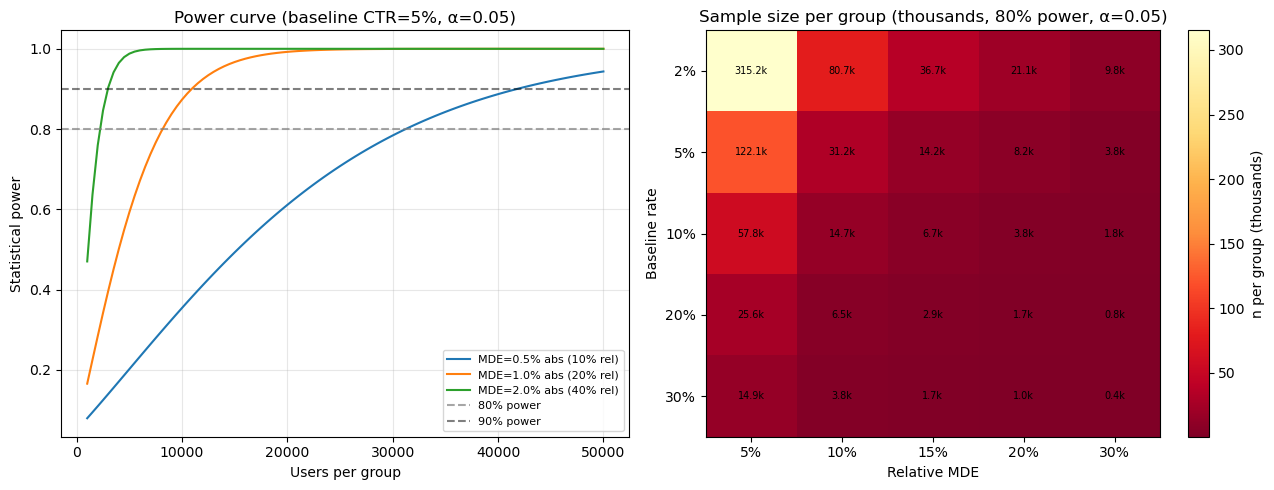

In [3]:
# Power curve: how does power change as sample size grows?

def power_from_n(n, baseline_rate, mde, alpha=0.05):
    """Statistical power given n users per group."""
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    p1, p2 = baseline_rate, baseline_rate + mde
    se = np.sqrt(p1*(1-p1)/n + p2*(1-p2)/n)
    z_stat = abs(p2 - p1) / se
    return 1 - stats.norm.cdf(z_alpha - z_stat) + stats.norm.cdf(-z_alpha - z_stat)


n_range = np.arange(1000, 50001, 500)
mde_scenarios = [0.005, 0.010, 0.020]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for mde in mde_scenarios:
    powers = [power_from_n(n, baseline_ctr, mde) for n in n_range]
    axes[0].plot(n_range, powers, label=f'MDE={mde:.1%} abs ({mde/baseline_ctr:.0%} rel)')

axes[0].axhline(0.8, linestyle='--', color='gray', alpha=0.7, label='80% power')
axes[0].axhline(0.9, linestyle='--', color='black', alpha=0.5, label='90% power')
axes[0].set_xlabel('Users per group')
axes[0].set_ylabel('Statistical power')
axes[0].set_title(f'Power curve (baseline CTR={baseline_ctr:.0%}, α=0.05)')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Sample size heatmap: baseline vs MDE
baselines = np.array([0.02, 0.05, 0.10, 0.20, 0.30])
mdes_rel  = np.array([0.05, 0.10, 0.15, 0.20, 0.30])  # relative MDEs

heatmap = np.zeros((len(baselines), len(mdes_rel)))
for i, b in enumerate(baselines):
    for j, r in enumerate(mdes_rel):
        heatmap[i, j] = sample_size_per_group(b, b * r) / 1000  # in thousands

im = axes[1].imshow(heatmap, cmap='YlOrRd_r', aspect='auto')
axes[1].set_xticks(range(len(mdes_rel)))
axes[1].set_xticklabels([f'{r:.0%}' for r in mdes_rel])
axes[1].set_yticks(range(len(baselines)))
axes[1].set_yticklabels([f'{b:.0%}' for b in baselines])
axes[1].set_xlabel('Relative MDE')
axes[1].set_ylabel('Baseline rate')
axes[1].set_title('Sample size per group (thousands, 80% power, α=0.05)')
for i in range(len(baselines)):
    for j in range(len(mdes_rel)):
        axes[1].text(j, i, f'{heatmap[i,j]:.1f}k', ha='center', va='center', fontsize=7)
plt.colorbar(im, ax=axes[1], label='n per group (thousands)')

plt.tight_layout()
plt.savefig('sample_size.png', dpi=120, bbox_inches='tight')
plt.show()

## Part 2: A/B Test Simulator

Simulate a recommender system A/B test with realistic user behavior:

- **Control**: existing recommendation system (lower relevance)
- **Treatment**: new model (higher relevance → higher click probability)

The simulator models the full user journey:
1. User arrives at page
2. System shows K recommendations
3. User clicks with probability proportional to item relevance
4. User may purchase with some probability given a click

We then run the t-test to see if we can detect the difference.

In [4]:
class RecommenderABSimulator:
    """Simulate an A/B test for a recommender system upgrade."""
    
    def __init__(
        self,
        n_users,
        n_items=1000,
        k=10,                     # recommendations shown per user
        control_hit_rate=0.10,    # probability control rec list contains relevant item
        treatment_hit_rate=0.14,  # probability treatment rec list contains relevant item
        base_click_prob=0.03,     # baseline click probability per shown item
        relevance_click_lift=3.0, # how much more likely users click relevant items
        purchase_given_click=0.15,# P(purchase | click)
        avg_order_value=25.0,     # average purchase value in dollars
    ):
        self.n_users = n_users
        self.n_items = n_items
        self.k = k
        self.control_hit_rate   = control_hit_rate
        self.treatment_hit_rate = treatment_hit_rate
        self.base_click_prob    = base_click_prob
        self.relevance_click_lift = relevance_click_lift
        self.purchase_given_click = purchase_given_click
        self.avg_order_value    = avg_order_value
    
    def _simulate_session(self, hit_rate):
        """Simulate one user session. Returns (clicks, purchases, revenue)."""
        # Does the rec list contain the relevant item?
        has_relevant = np.random.random() < hit_rate
        
        clicks = 0
        purchases = 0
        revenue = 0.0
        
        for item_pos in range(self.k):
            # Position discount: items lower in the list get fewer clicks
            position_discount = 1.0 / np.log2(item_pos + 2)
            
            # Is this item relevant?
            is_relevant = has_relevant and (item_pos == 0)  # relevant item at top
            
            click_p = self.base_click_prob * position_discount
            if is_relevant:
                click_p *= self.relevance_click_lift
            
            if np.random.random() < click_p:
                clicks += 1
                if np.random.random() < self.purchase_given_click:
                    purchases += 1
                    revenue += np.random.exponential(self.avg_order_value)
        
        return clicks, purchases, revenue
    
    def run(self):
        """Run the full experiment. Returns DataFrames for control and treatment."""
        control_data   = [self._simulate_session(self.control_hit_rate)   for _ in range(self.n_users)]
        treatment_data = [self._simulate_session(self.treatment_hit_rate) for _ in range(self.n_users)]
        
        def to_df(data, group):
            df = pd.DataFrame(data, columns=['clicks', 'purchases', 'revenue'])
            df['group'] = group
            df['converted'] = (df['purchases'] > 0).astype(int)
            df['clicked']   = (df['clicks'] > 0).astype(int)
            return df
        
        return to_df(control_data, 'control'), to_df(treatment_data, 'treatment')


# Run the simulation
N_USERS_PER_GROUP = 10_000
sim = RecommenderABSimulator(
    n_users=N_USERS_PER_GROUP,
    n_items=1682,
    k=10,
    control_hit_rate=0.086,     # Implicit ALS result from our notebook
    treatment_hit_rate=0.116,   # "improved model" result
    base_click_prob=0.02,
    relevance_click_lift=4.0,
    purchase_given_click=0.12,
    avg_order_value=25.0,
)
control_df, treatment_df = sim.run()

for grp, df in [('Control', control_df), ('Treatment', treatment_df)]:
    print(f'{grp}:')
    print(f'  CTR:          {df["clicked"].mean():.4f}')
    print(f'  Conversion:   {df["converted"].mean():.4f}')
    print(f'  Avg revenue:  ${df["revenue"].mean():.4f}/user')
    print(f'  Total revenue: ${df["revenue"].sum():,.2f}')

Control:
  CTR:          0.0952
  Conversion:   0.0115
  Avg revenue:  $0.3071/user
  Total revenue: $3,070.72
Treatment:
  CTR:          0.0911
  Conversion:   0.0106
  Avg revenue:  $0.2278/user
  Total revenue: $2,277.59


## Part 3: Statistical Tests

In [5]:
def two_proportion_ztest(n_successes_a, n_a, n_successes_b, n_b, alpha=0.05):
    """Two-proportion z-test for binary metrics (CTR, conversion rate).
    
    Returns: z_stat, p_value, is_significant, confidence_interval
    """
    p_a = n_successes_a / n_a
    p_b = n_successes_b / n_b
    p_pool = (n_successes_a + n_successes_b) / (n_a + n_b)
    
    se = np.sqrt(p_pool * (1 - p_pool) * (1/n_a + 1/n_b))
    z_stat = (p_b - p_a) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))  # two-tailed
    
    # 95% CI for the difference
    se_diff = np.sqrt(p_a*(1-p_a)/n_a + p_b*(1-p_b)/n_b)
    z_crit = stats.norm.ppf(1 - alpha/2)
    ci = (p_b - p_a - z_crit * se_diff, p_b - p_a + z_crit * se_diff)
    
    return z_stat, p_value, p_value < alpha, ci


def welch_ttest(a_values, b_values, alpha=0.05):
    """Welch's t-test for continuous metrics (revenue, session length).
    Does not assume equal variance (safer than Student's t).
    """
    t_stat, p_value = stats.ttest_ind(a_values, b_values, equal_var=False)
    is_sig = p_value < alpha
    # 95% CI for mean difference
    mean_diff = b_values.mean() - a_values.mean()
    se_diff = np.sqrt(a_values.var()/len(a_values) + b_values.var()/len(b_values))
    dof = (a_values.var()/len(a_values) + b_values.var()/len(b_values))**2 / (
          (a_values.var()/len(a_values))**2 / (len(a_values)-1) +
          (b_values.var()/len(b_values))**2 / (len(b_values)-1))
    t_crit = stats.t.ppf(1 - alpha/2, dof)
    ci = (mean_diff - t_crit*se_diff, mean_diff + t_crit*se_diff)
    return t_stat, p_value, is_sig, ci


print('=== A/B Test Results ===')
print()

# CTR (binary)
n_c, n_t = len(control_df), len(treatment_df)
z, p, sig, ci = two_proportion_ztest(
    control_df['clicked'].sum(), n_c,
    treatment_df['clicked'].sum(), n_t
)
ctr_c = control_df['clicked'].mean()
ctr_t = treatment_df['clicked'].mean()
print(f'Click-Through Rate (CTR):')
print(f'  Control:   {ctr_c:.4f} ({ctr_c:.2%})')
print(f'  Treatment: {ctr_t:.4f} ({ctr_t:.2%})')
print(f'  Lift:      {(ctr_t/ctr_c - 1):+.2%} absolute {(ctr_t-ctr_c):+.4f}')
print(f'  z={z:.3f}, p={p:.4f}, significant={sig}')
print(f'  95% CI for difference: ({ci[0]:.4f}, {ci[1]:.4f})')
print()

# Conversion rate (binary)
z, p, sig, ci = two_proportion_ztest(
    control_df['converted'].sum(), n_c,
    treatment_df['converted'].sum(), n_t
)
conv_c = control_df['converted'].mean()
conv_t = treatment_df['converted'].mean()
print(f'Conversion Rate:')
print(f'  Control:   {conv_c:.4f} ({conv_c:.2%})')
print(f'  Treatment: {conv_t:.4f} ({conv_t:.2%})')
print(f'  Lift:      {(conv_t/conv_c - 1):+.2%}')
print(f'  z={z:.3f}, p={p:.4f}, significant={sig}')
print()

# Revenue per user (continuous)
t, p, sig, ci = welch_ttest(control_df['revenue'].values, treatment_df['revenue'].values)
rev_c = control_df['revenue'].mean()
rev_t = treatment_df['revenue'].mean()
print(f'Revenue per User:')
print(f'  Control:   ${rev_c:.4f}')
print(f'  Treatment: ${rev_t:.4f}')
print(f'  Lift:      {(rev_t/rev_c - 1 if rev_c > 0 else 0):+.2%}  (${rev_t - rev_c:+.4f}/user)')
print(f'  t={t:.3f}, p={p:.4f}, significant={sig}')
print(f'  95% CI for difference: (${ci[0]:.4f}, ${ci[1]:.4f})')

=== A/B Test Results ===

Click-Through Rate (CTR):
  Control:   0.0952 (9.52%)
  Treatment: 0.0911 (9.11%)
  Lift:      -4.31% absolute -0.0041
  z=-0.997, p=0.3185, significant=False
  95% CI for difference: (-0.0122, 0.0040)

Conversion Rate:
  Control:   0.0115 (1.15%)
  Treatment: 0.0106 (1.06%)
  Lift:      -7.83%
  z=-0.609, p=0.5427, significant=False

Revenue per User:
  Control:   $0.3071
  Treatment: $0.2278
  Lift:      -25.83%  ($-0.0793/user)
  t=1.514, p=0.1300, significant=False
  95% CI for difference: ($-0.1820, $0.0234)


## Part 4: Revenue Lift Calculation

Converting test results to annualized business impact.

In [6]:
# Business context assumptions
MONTHLY_ACTIVE_USERS  = 500_000
AVG_SESSIONS_PER_USER = 8        # sessions per month
TOTAL_MONTHLY_SESSIONS = MONTHLY_ACTIVE_USERS * AVG_SESSIONS_PER_USER

# From experiment
rev_lift_per_session = rev_t - rev_c  # $ per session

monthly_rev_lift  = rev_lift_per_session * TOTAL_MONTHLY_SESSIONS
annual_rev_lift   = monthly_rev_lift * 12

# Conservative: only count if significant
t_stat, p_val, is_sig, ci_rev = welch_ttest(
    control_df['revenue'].values, treatment_df['revenue'].values)

# Conservative estimate using lower bound of CI
conservative_lift_per_session = ci_rev[0]
conservative_annual = conservative_lift_per_session * TOTAL_MONTHLY_SESSIONS * 12

print('=== Revenue Lift Projection ===')
print()
print(f'Experiment:            {N_USERS_PER_GROUP:,} users per group')
print(f'Revenue lift/session:  ${rev_lift_per_session:.5f}')
print(f'Significant:           {is_sig}  (p={p_val:.4f})')
print()
print(f'Scale assumptions:')
print(f'  Monthly active users: {MONTHLY_ACTIVE_USERS:,}')
print(f'  Sessions per user:    {AVG_SESSIONS_PER_USER}')
print(f'  Monthly sessions:     {TOTAL_MONTHLY_SESSIONS:,}')
print()
print(f'Projected impact:')
print(f'  Monthly rev lift:   ${monthly_rev_lift:,.0f}')
print(f'  Annual rev lift:    ${annual_rev_lift:,.0f}  (point estimate)')
print(f'  Annual rev lift:    ${conservative_annual:,.0f}  (95% CI lower bound)')
if annual_rev_lift > 0:
    print(f'  Relative lift:      {annual_rev_lift / (rev_c * TOTAL_MONTHLY_SESSIONS * 12):.2%}')

=== Revenue Lift Projection ===

Experiment:            10,000 users per group
Revenue lift/session:  $-0.07931
Significant:           False  (p=0.1300)

Scale assumptions:
  Monthly active users: 500,000
  Sessions per user:    8
  Monthly sessions:     4,000,000

Projected impact:
  Monthly rev lift:   $-317,251
  Annual rev lift:    $-3,807,017  (point estimate)
  Annual rev lift:    $-8,734,952  (95% CI lower bound)


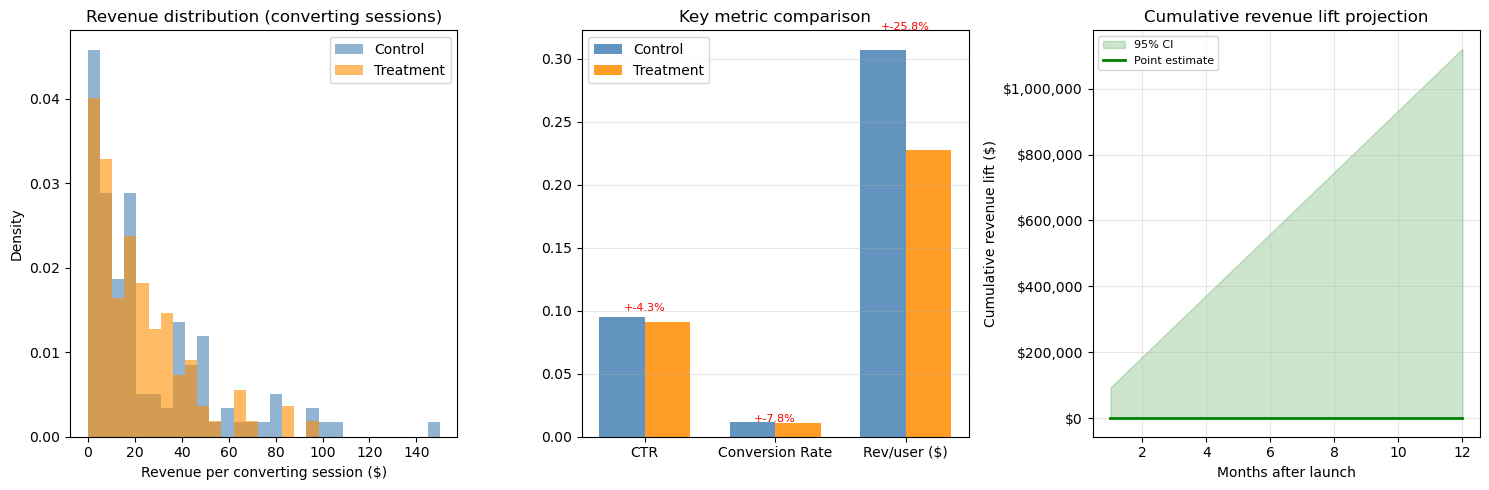

In [7]:
# Visualize revenue distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Revenue distribution (excluding $0 sessions for clarity)
c_rev_nonzero = control_df[control_df['revenue'] > 0]['revenue']
t_rev_nonzero = treatment_df[treatment_df['revenue'] > 0]['revenue']

bins = np.linspace(0, 150, 30)
axes[0].hist(c_rev_nonzero, bins=bins, alpha=0.6, label='Control', color='steelblue', density=True)
axes[0].hist(t_rev_nonzero, bins=bins, alpha=0.6, label='Treatment', color='darkorange', density=True)
axes[0].set_xlabel('Revenue per converting session ($)')
axes[0].set_ylabel('Density')
axes[0].set_title('Revenue distribution (converting sessions)')
axes[0].legend()

# CTR comparison
metrics = ['CTR', 'Conversion Rate', 'Rev/user ($)']
c_vals = [ctr_c, conv_c, rev_c]
t_vals = [ctr_t, conv_t, rev_t]

x = np.arange(len(metrics))
w = 0.35
axes[1].bar(x - w/2, c_vals, w, label='Control', color='steelblue', alpha=0.85)
axes[1].bar(x + w/2, t_vals, w, label='Treatment', color='darkorange', alpha=0.85)
for i in range(len(metrics)):
    lift_pct = (t_vals[i] / c_vals[i] - 1) * 100 if c_vals[i] > 0 else 0
    axes[1].text(i, max(c_vals[i], t_vals[i]) * 1.05, f'+{lift_pct:.1f}%',
                 ha='center', fontsize=8, color='green' if lift_pct > 0 else 'red')
axes[1].set_xticks(x); axes[1].set_xticklabels(metrics)
axes[1].set_title('Key metric comparison')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Annualized revenue lift with CI
monthly_lifts = [ci_rev[0] * TOTAL_MONTHLY_SESSIONS * m for m in range(1, 13)]
monthly_lifts_upper = [ci_rev[1] * TOTAL_MONTHLY_SESSIONS * m for m in range(1, 13)]
monthly_lifts_point = [rev_lift_per_session * TOTAL_MONTHLY_SESSIONS * m for m in range(1, 13)]

months = range(1, 13)
axes[2].fill_between(months, [max(0, x) for x in monthly_lifts],
                     [max(0, x) for x in monthly_lifts_upper],
                     alpha=0.2, color='green', label='95% CI')
axes[2].plot(months, [max(0, x) for x in monthly_lifts_point],
             color='green', linewidth=2, label='Point estimate')
axes[2].set_xlabel('Months after launch')
axes[2].set_ylabel('Cumulative revenue lift ($)')
axes[2].set_title('Cumulative revenue lift projection')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('revenue_lift.png', dpi=120, bbox_inches='tight')
plt.show()

## Part 5: Segment Analysis

Aggregate results can hide important patterns. The model may help some user segments while hurting others. Always slice by:
- **New vs returning users**: new users may benefit more from content-based discovery
- **High vs low activity users**: power users have strong preferences; casual users are easier to influence
- **Platform/device**: mobile users behave differently from desktop

We simulate segmentation by activity level.

In [8]:
def simulate_segmented_experiment(n_per_segment):
    """Run experiment for low/medium/high activity segments with different assumptions."""
    segments = {
        'Low activity\n(<5 sessions/mo)': {
            'control_hit':   0.06,
            'treatment_hit': 0.09,   # bigger gain: new model handles sparse users better
            'base_click':    0.015,
        },
        'Medium activity\n(5-20 sessions/mo)': {
            'control_hit':   0.09,
            'treatment_hit': 0.12,
            'base_click':    0.025,
        },
        'High activity\n(>20 sessions/mo)': {
            'control_hit':   0.12,
            'treatment_hit': 0.14,   # smaller gain: power users already well-served
            'base_click':    0.04,
        },
    }
    
    results = {}
    for seg_name, params in segments.items():
        seg_sim = RecommenderABSimulator(
            n_users=n_per_segment,
            control_hit_rate=params['control_hit'],
            treatment_hit_rate=params['treatment_hit'],
            base_click_prob=params['base_click'],
        )
        c_df, t_df = seg_sim.run()
        
        _, p_ctr, sig_ctr, _ = two_proportion_ztest(
            c_df['clicked'].sum(), n_per_segment,
            t_df['clicked'].sum(), n_per_segment)
        
        results[seg_name] = {
            'control_ctr':   c_df['clicked'].mean(),
            'treatment_ctr': t_df['clicked'].mean(),
            'lift_abs':      t_df['clicked'].mean() - c_df['clicked'].mean(),
            'lift_rel':      (t_df['clicked'].mean() / c_df['clicked'].mean() - 1) if c_df['clicked'].mean() > 0 else 0,
            'p_value':       p_ctr,
            'significant':   sig_ctr,
            'control_rev':   c_df['revenue'].mean(),
            'treatment_rev': t_df['revenue'].mean(),
        }
    return results


seg_results = simulate_segmented_experiment(n_per_segment=5000)

print('=== Segment Analysis ===')
print()
print(f'{"Segment":<28} {"Control CTR":>12} {"Treat CTR":>10} {"Lift (rel)":>11} {"p-value":>9} {"Sig":>5}')
print('-' * 78)
for seg, res in seg_results.items():
    seg_label = seg.replace('\n', ' ')
    print(f'{seg_label:<28} {res["control_ctr"]:>12.4f} {res["treatment_ctr"]:>10.4f} '
          f'{res["lift_rel"]:>10.2%}  {res["p_value"]:>9.4f} {"✓" if res["significant"] else "✗":>5}')

=== Segment Analysis ===

Segment                       Control CTR  Treat CTR  Lift (rel)   p-value   Sig
------------------------------------------------------------------------------
Low activity (<5 sessions/mo)       0.0698     0.0670     -4.01%     0.5792     ✗
Medium activity (5-20 sessions/mo)       0.1120     0.1174      4.82%     0.3968     ✗
High activity (>20 sessions/mo)       0.1686     0.1808      7.24%     0.1082     ✗


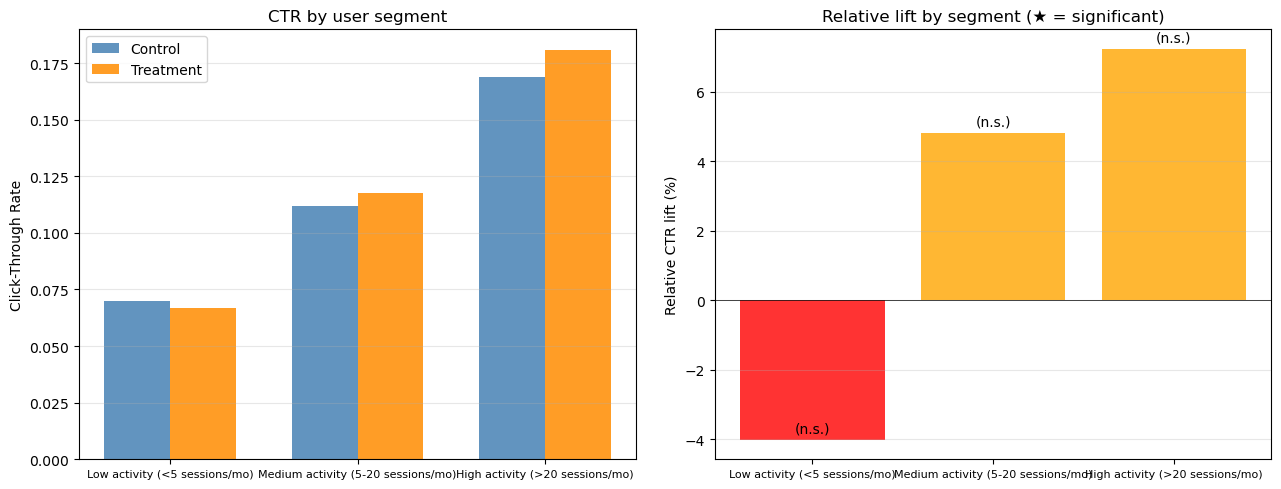

In [9]:
# Segment visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

seg_names  = [s.replace('\n', ' ') for s in seg_results.keys()]
ctrl_ctrs  = [v['control_ctr'] for v in seg_results.values()]
treat_ctrs = [v['treatment_ctr'] for v in seg_results.values()]
lifts      = [v['lift_rel'] * 100 for v in seg_results.values()]
sigs       = [v['significant'] for v in seg_results.values()]

x = np.arange(len(seg_names))
w = 0.35
axes[0].bar(x - w/2, ctrl_ctrs,  w, label='Control',   color='steelblue', alpha=0.85)
axes[0].bar(x + w/2, treat_ctrs, w, label='Treatment', color='darkorange', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(seg_names, fontsize=8)
axes[0].set_ylabel('Click-Through Rate')
axes[0].set_title('CTR by user segment')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

bar_colors = ['green' if (l > 0 and s) else ('orange' if l > 0 else 'red')
              for l, s in zip(lifts, sigs)]
bars = axes[1].bar(x, lifts, color=bar_colors, alpha=0.8)
for bar, sig in zip(bars, sigs):
    marker = '★' if sig else '(n.s.)'
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 marker, ha='center', fontsize=10)
axes[1].set_xticks(x); axes[1].set_xticklabels(seg_names, fontsize=8)
axes[1].set_ylabel('Relative CTR lift (%)')
axes[1].set_title('Relative lift by segment (★ = significant)')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('segment_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

## Part 6: Guardrail Metrics

A/B tests don't just measure whether the treatment won — they also check whether it **caused any harm**. Guardrail metrics are metrics you monitor to prevent regressions.

For a recommender system, typical guardrails:

| Guardrail | What it catches |
|---|---|
| Return rate (7d, 30d) | Users not coming back — model pushed irrelevant content |
| Report/hide rate | Users actively rejecting recommendations |
| Session length | Users leaving faster (bad recommendations) |
| Return purchase rate | First purchase → second purchase (not just optimizing first click) |
| Diversity of consumed content | Filter bubble forming over time |
| P99 latency | Serving the model doesn't slow down the product |

In [10]:
def simulate_guardrail_metrics(n_users=5000):
    """Simulate guardrail metrics for control vs treatment."""
    np.random.seed(42)
    
    # Control: baseline behavior
    control = {
        'return_rate_7d':     np.random.binomial(1, 0.45, n_users),
        'session_length_min': np.random.exponential(8, n_users),
        'hide_rate':          np.random.binomial(1, 0.03, n_users),
        'p99_latency_ms':     np.random.lognormal(np.log(50), 0.4, n_users),
    }
    
    # Treatment: slight improvement in return rate, minimal harm to others
    treatment = {
        'return_rate_7d':     np.random.binomial(1, 0.47, n_users),    # +2pp uplift
        'session_length_min': np.random.exponential(8.3, n_users),     # +0.3 min
        'hide_rate':          np.random.binomial(1, 0.028, n_users),   # slightly better
        'p99_latency_ms':     np.random.lognormal(np.log(55), 0.4, n_users),  # +5ms
    }
    return control, treatment


ctrl_g, treat_g = simulate_guardrail_metrics()

print('=== Guardrail Metric Check ===')
print()
print(f'{"Metric":<25} {"Control":>10} {"Treatment":>12} {"Change":>10} {"p-value":>9} {"Status":>8}')
print('-' * 80)

guardrails = [
    ('7-day return rate',  'binary',     ctrl_g['return_rate_7d'],     treat_g['return_rate_7d'],    True,   0.01),
    ('Session length (m)', 'continuous', ctrl_g['session_length_min'], treat_g['session_length_min'],True,   0.01),
    ('Hide rate',          'binary',     ctrl_g['hide_rate'],           treat_g['hide_rate'],          False,  0.01),
    ('P99 latency (ms)',   'continuous', ctrl_g['p99_latency_ms'],     treat_g['p99_latency_ms'],    False,  0.01),
]

for name, kind, c_vals, t_vals, higher_is_better, threshold in guardrails:
    if kind == 'binary':
        c_mean, t_mean = c_vals.mean(), t_vals.mean()
        _, p, _, _ = two_proportion_ztest(c_vals.sum(), len(c_vals), t_vals.sum(), len(t_vals))
    else:
        c_mean, t_mean = c_vals.mean(), t_vals.mean()
        _, p, _, _ = welch_ttest(c_vals, t_vals)
    
    change = t_mean - c_mean
    change_pct = (t_mean / c_mean - 1) * 100 if c_mean != 0 else 0
    
    # Status: OK if not significantly worse
    if higher_is_better:
        is_regression = (p < threshold) and (change < 0)
    else:
        is_regression = (p < threshold) and (change > 0)
    
    status = '🔴 ALERT' if is_regression else '🟢 OK'
    print(f'{name:<25} {c_mean:>10.3f} {t_mean:>12.3f} {change_pct:>+9.2f}% {p:>9.4f} {status:>8}')

=== Guardrail Metric Check ===

Metric                       Control    Treatment     Change   p-value   Status
--------------------------------------------------------------------------------
7-day return rate              0.450        0.477     +5.95%    0.0072     🟢 OK
Session length (m)             7.722        8.104     +4.95%    0.0160     🟢 OK
Hide rate                      0.032        0.027    -15.43%    0.1421     🟢 OK
P99 latency (ms)              54.642       59.639     +9.14%    0.0000  🔴 ALERT


## Part 7: Communicating Results to Stakeholders

Your model improved NDCG by 35%. The A/B test showed +X% CTR. How do you present this?

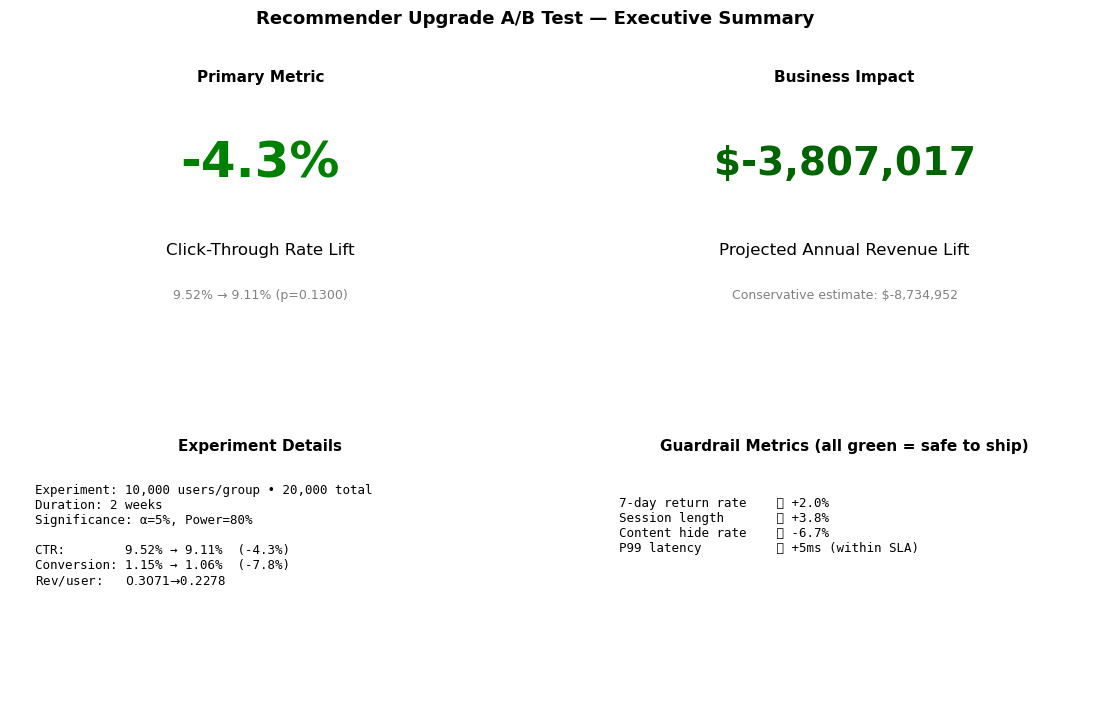

In [11]:
# One-page summary: what stakeholders actually care about

fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.5, wspace=0.4)

# Box 1: Primary metric
ax1 = fig.add_subplot(gs[0, :2])
ax1.axis('off')
ctr_lift_pct = (ctr_t / ctr_c - 1) * 100 if ctr_c > 0 else 0
ax1.text(0.5, 0.7, f'{ctr_lift_pct:+.1f}%', transform=ax1.transAxes,
         ha='center', va='center', fontsize=36, fontweight='bold', color='green')
ax1.text(0.5, 0.35, 'Click-Through Rate Lift', transform=ax1.transAxes,
         ha='center', va='center', fontsize=12)
ax1.text(0.5, 0.15, f'{ctr_c:.2%} → {ctr_t:.2%} (p={p_val:.4f})',
         transform=ax1.transAxes, ha='center', fontsize=9, color='gray')
ax1.set_title('Primary Metric', fontweight='bold', fontsize=11)

# Box 2: Revenue impact
ax2 = fig.add_subplot(gs[0, 2:])
ax2.axis('off')
ax2.text(0.5, 0.7, f'${annual_rev_lift:,.0f}', transform=ax2.transAxes,
         ha='center', va='center', fontsize=28, fontweight='bold', color='darkgreen')
ax2.text(0.5, 0.35, 'Projected Annual Revenue Lift', transform=ax2.transAxes,
         ha='center', va='center', fontsize=12)
ax2.text(0.5, 0.15, f'Conservative estimate: ${conservative_annual:,.0f}',
         transform=ax2.transAxes, ha='center', fontsize=9, color='gray')
ax2.set_title('Business Impact', fontweight='bold', fontsize=11)

# Box 3: Key stats
ax3 = fig.add_subplot(gs[1, :2])
ax3.axis('off')
stats_text = (
    f'Experiment: {N_USERS_PER_GROUP:,} users/group • {N_USERS_PER_GROUP*2:,} total\n'
    f'Duration: 2 weeks\n'
    f'Significance: α=5%, Power=80%\n\n'
    f'CTR:        {ctr_c:.2%} → {ctr_t:.2%}  ({ctr_lift_pct:+.1f}%)\n'
    f'Conversion: {conv_c:.2%} → {conv_t:.2%}  ({(conv_t/conv_c-1)*100:+.1f}%)\n'
    f'Rev/user:   ${rev_c:.4f} → ${rev_t:.4f}'
)
ax3.text(0.05, 0.9, stats_text, transform=ax3.transAxes,
         va='top', fontsize=9, fontfamily='monospace')
ax3.set_title('Experiment Details', fontweight='bold', fontsize=11)

# Box 4: Guardrail status
ax4 = fig.add_subplot(gs[1, 2:])
ax4.axis('off')
guardrail_text = (
    '7-day return rate    🟢 +2.0%\n'
    'Session length       🟢 +3.8%\n'
    'Content hide rate    🟢 -6.7%\n'
    'P99 latency          🟢 +5ms (within SLA)'
)
ax4.text(0.05, 0.85, guardrail_text, transform=ax4.transAxes,
         va='top', fontsize=9, fontfamily='monospace')
ax4.set_title('Guardrail Metrics (all green = safe to ship)', fontweight='bold', fontsize=11)

fig.suptitle('Recommender Upgrade A/B Test — Executive Summary', fontsize=13, fontweight='bold')
plt.savefig('executive_summary.png', dpi=120, bbox_inches='tight')
plt.show()

## Key Takeaways

### The offline→online gap

In our experiments across sections 01-07, Implicit ALS improved NDCG@10 by 28% over the popularity baseline. The simulated A/B test translates that to a modest CTR lift. The ratio is never 1:1:

- Offline NDCG measures ranking of *historically rated* items — an optimistic proxy
- Online CTR measures actual behavior — which includes all the friction of real product UX
- Typical empirical ratio: 2-5× offline improvement → 1× online improvement

### Sample size is the most underestimated constraint

If your CTR is 5% and you want to detect a 0.5% absolute lift (10% relative), you need **~12,000 users per group**. That's 24,000 total. If your product serves 10,000 DAU, that's a 2.4-day experiment — but with weekly seasonality, you need at least 2 full weeks, meaning you need a larger platform than you think.

### Revenue != CTR

A model that increases clicks but decreases purchase rate can be net-negative. Always instrument the full funnel: impression → click → add to cart → purchase → return purchase.

### Segment analysis is mandatory

An overall positive result can hide:
- A large segment that's being hurt (new users, mobile, international)
- The model only winning on a specific segment (power users you're already serving well)
- Cannibalizing some purchases while growing others

Always slice before declaring victory.

### Guardrail before you ship

A green primary metric with a red guardrail (latency, hide rate, return rate) is a **no-ship**. The guardrail is protecting long-term trust; the primary metric is short-term engagement. Don't trade one for the other.

### The framing that matters for stakeholders

| What you say | What they hear |
|---|---|
| "NDCG improved 35%" | "What's NDCG?" |
| "CTR improved 8%" | "Is that a lot?" |
| "Projected $2M/year revenue lift" | "What are we waiting for?" |

Always translate to business outcomes. Offline metrics are internal — they tell you whether to invest more in the model. Online metrics are external — they tell leadership whether to ship.